In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb

import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.stats import pearsonr, spearmanr

# Settings

In [3]:
TEXT_WIDTH = 8.27  # in
DPI = 360

In [4]:
def set_font_size(font_size):
    plt.rc('font', size=font_size)          # controls default text sizes
    plt.rc('axes', titlesize=font_size)     # fontsize of the axes title
    plt.rc('axes', labelsize=font_size)     # fontsize of the x and y labels
    plt.rc('xtick', labelsize=font_size)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=font_size)    # fontsize of the tick labels
    plt.rc('legend', fontsize=font_size, title_fontsize=font_size)    # legend fontsize
    plt.rc('figure', titlesize=font_size)   # fontsize of the figure title

In [5]:
sb.set(context='paper', style='whitegrid')
plt.rc('grid', linewidth=0.3)
sb.set_palette('colorblind')
set_font_size(10)

In [6]:
palette_epitopes = {
    "OVA": "#1F77B4",
    "GP33": "#009E73",
    "M45": "#6A3D9A",
}

# Helper functions

In [7]:
def p_2_sign(v):
    if v < 0.0001:
        return '****'
    if v < 0.001:
        return '***'
    if v < 0.01:
        return '**'
    if v < 0.05:
        return '*'
    return ''

# Load data

In [8]:
epitopes = ['OVA', 'GP33', 'M45', ]

In [9]:
dfs_prediction = {epi: pd.read_csv(f'../results/{epi if epi!="OVA" else "siinfekl_reactive"}_prediction_scores.csv',
                                  index_col=0)
                 for epi in epitopes}
dfs_prediction['OVA'] = dfs_prediction['OVA'].rename(columns={
    'prediction_siinfekl_reactive_0': 'prediction_OVA_0',
    'prediction_siinfekl_reactive_1': 'prediction_OVA_1',
    'prediction_siinfekl_reactive_2': 'prediction_OVA_2',
    'prediction_siinfekl_reactive_3': 'prediction_OVA_3',
    'prediction_siinfekl_reactive_4': 'prediction_OVA_4',
    'prediction_siinfekl_reactive_ensemble': 'prediction_OVA_ensemble',
})

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_13040/862115569.py:1: DtypeWarning: Columns (1,2,3,5,8,10,22,23,27,54) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs_prediction = {epi: pd.read_csv(f'../results/{epi if epi!="OVA" else "siinfekl_reactive"}_prediction_scores.csv',


# Plotting function

In [10]:
from sklearn.metrics import roc_curve, auc

In [11]:
threshold = 0.5

In [12]:
def format_subplots(i, ax):
    sb.despine(ax=ax)
    ax.grid(False)
    
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)
    
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
    ax.tick_params(axis='x', colors='black', width=1, pad=1)
    ax.tick_params(axis='y', colors='black', width=1, pad=1)
    
    ax.tick_params(axis='both', length=2)
    
    if i < 2:
        ax.set_xlabel(None)
        ax.set_xticks([])
        ax.set_xticklabels([])
    else:
        ax.set_xlabel(ax.get_xlabel(), labelpad=0)
        
    if i%2 == 1:
        ax.set_ylabel(None)
        ax.set_yticks([])
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(ax.get_ylabel(), labelpad=0)

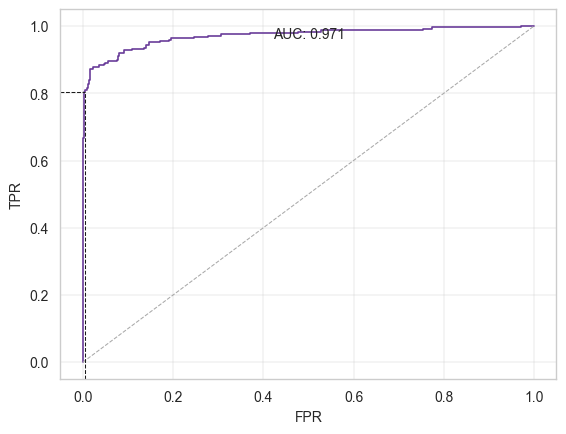

In [13]:
def plot_auc_curve(epi, ax=None):
    df_ = dfs_prediction[epi]
    df = df_[df_['group_stratified_split_0']=='test'].copy()
    y_true = df['specificity'] != 'not_identified'
    y_score = df[f'prediction_{epi}_ensemble']
        
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    ax = sb.lineplot(x=fpr, y=tpr, ax=ax, color=palette_epitopes[epi], 
                     errorbar=None, estimator=None)
    sb.lineplot(x=[0, 1], y=[0, 1], ax=ax, linestyle="--", color='darkgray', linewidth=0.75)

    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    
    roc_auc = auc(fpr, tpr)
    ax.set_title(f'AUC: {roc_auc:.3f}', y=0.9)
    
    idx = np.argmin(np.abs(thresholds - threshold))
    fpr_at_thresh = fpr[idx]
    tpr_at_thresh = tpr[idx]
    
    xlim = ax.get_xlim()
    ylim = ax.get_xlim()
    ax.vlines(x=fpr_at_thresh, ymin=ylim[0], ymax=tpr_at_thresh, colors='k', linestyles='--', linewidth=0.75)
    ax.hlines(y=tpr_at_thresh, xmin=xlim[0], xmax=fpr_at_thresh, colors='k', linestyles='--', linewidth=0.75)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
plot_auc_curve('M45')

0.9852216748768473


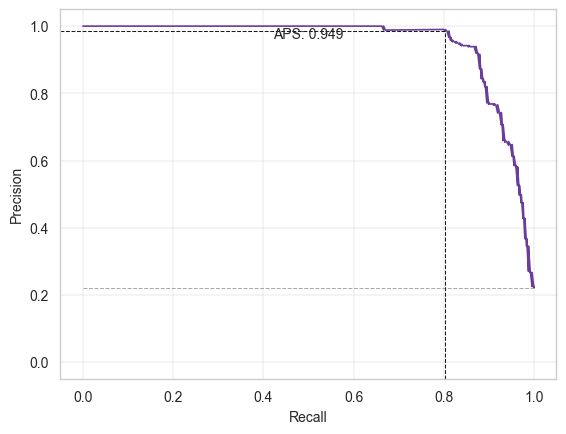

In [14]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curve(epi, ax=None):
    df_ = dfs_prediction[epi]
    df = df_[df_['group_stratified_split_0']=='test'].copy()
    y_true = df['specificity'] != 'not_identified'
    y_score = df[f'prediction_{epi}_ensemble']
    
    # Compute precision, recall, thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    # Plot curve
    ax = sb.lineplot(x=recall, y=precision, ax=ax, color=palette_epitopes[epi], 
                     errorbar=None, estimator=None)
    
    # Plot baseline (positive fraction)
    pos_frac = y_true.mean()
    sb.lineplot(x=[0, 1], y=[pos_frac, pos_frac], ax=ax, linestyle="--", color='darkgray', linewidth=0.75)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    
    aps = average_precision_score(y_true, y_score)
    ax.set_title(f'APS: {aps:.3f}', y=0.9)
    
    idx = np.argmin(np.abs(thresholds - threshold))
    recall_at_thresh = recall[idx]
    precision_at_thresh = precision[idx]
    
    xlim = ax.get_xlim()
    ylim = ax.get_xlim()
    ax.vlines(x=recall_at_thresh, ymin=ylim[0], ymax=precision_at_thresh, colors='k', linestyles='--', linewidth=0.75)
    ax.hlines(y=precision_at_thresh, xmin=xlim[0], xmax=recall_at_thresh, colors='k', linestyles='--', linewidth=0.75)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    print(precision_at_thresh)
    
    
plot_pr_curve('M45')

# Supplementary Figure

In [15]:
def format_subplots(i, ax):
    sb.despine(ax=ax)
    ax.grid(False)
    
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)
    
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
    ax.tick_params(axis='x', colors='black', width=1, pad=1)
    ax.tick_params(axis='y', colors='black', width=1, pad=1)
    
    ax.tick_params(axis='both', length=2)
    
    if i < 2:
        ax.set_xlabel(None)
        ax.set_xticks([])
        ax.set_xticklabels([])
    else:
        ax.set_xlabel(ax.get_xlabel(), labelpad=0)
        
    if i%2 == 1:
        ax.set_ylabel(None)
        ax.set_yticks([])
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(ax.get_ylabel(), labelpad=0)

0.8764805414551607
0.9224806201550387
0.9852216748768473


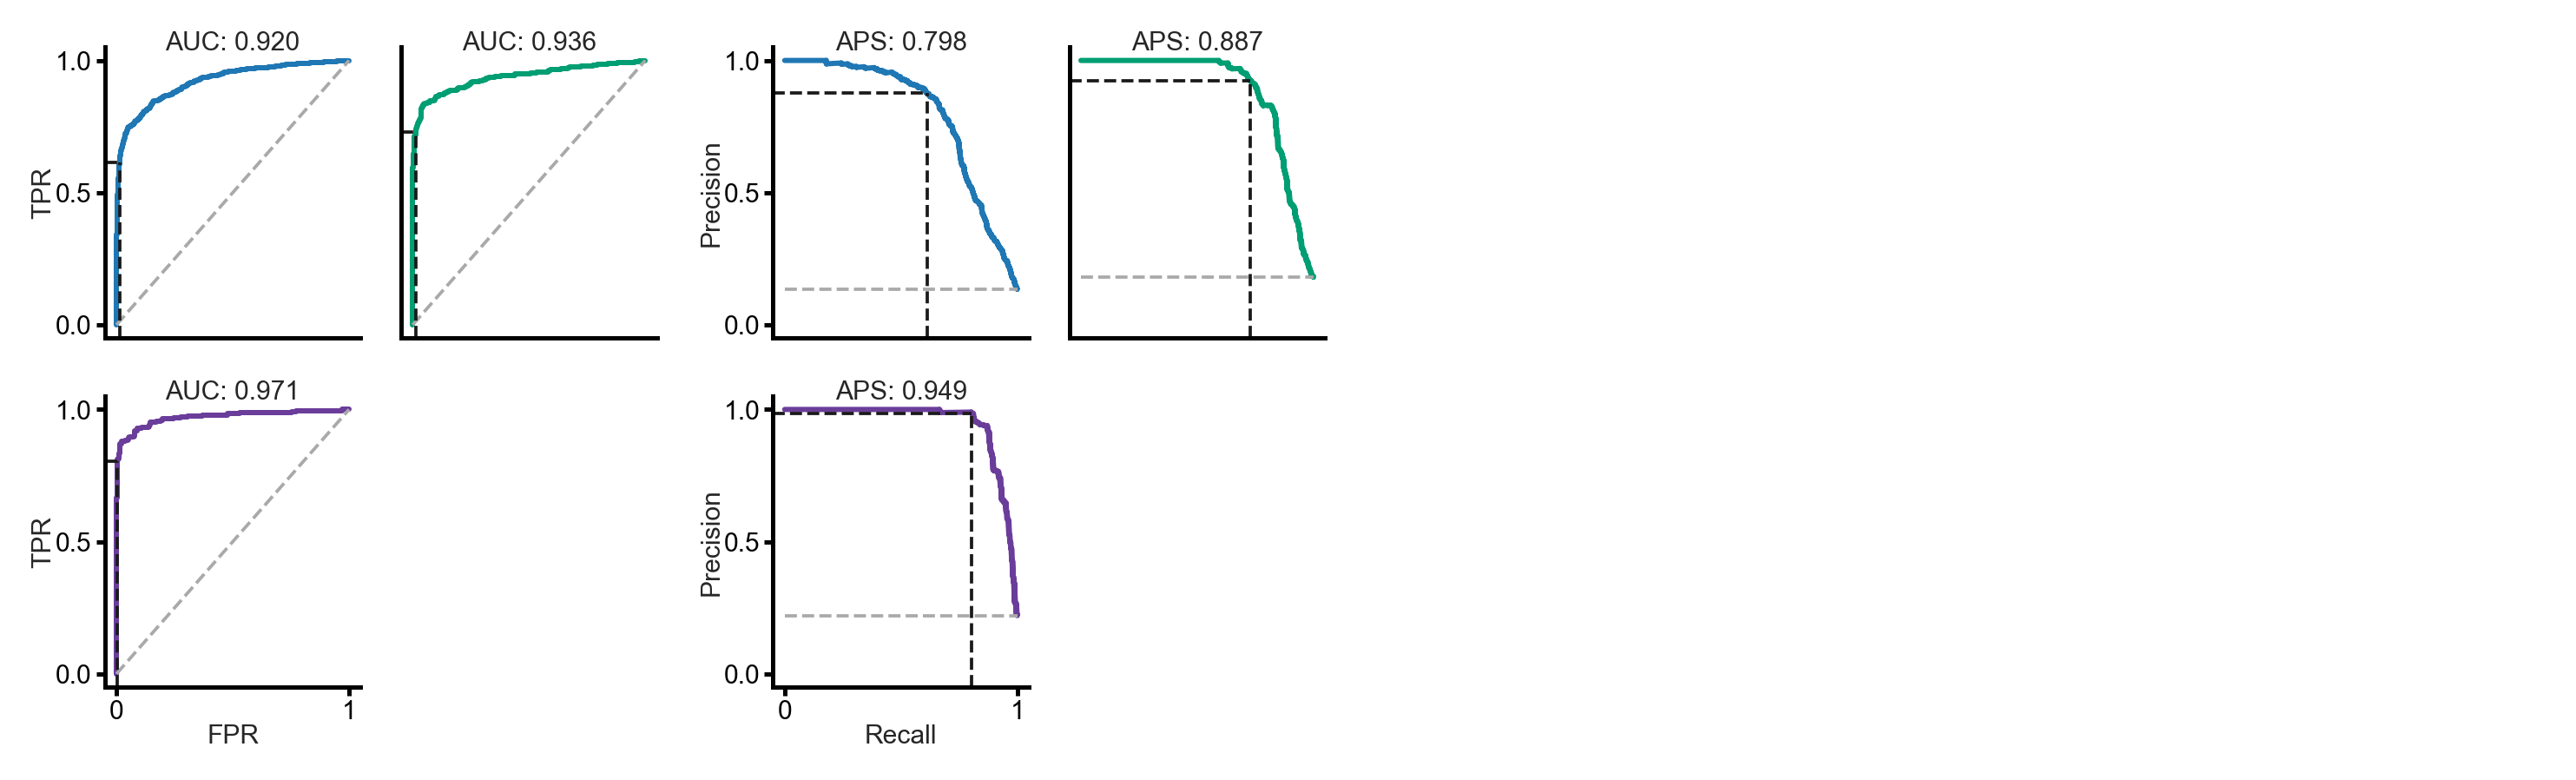

In [16]:
scale = 1
fig = plt.figure(figsize=(TEXT_WIDTH * scale, TEXT_WIDTH * scale * 0.3), #0.65
                 dpi=DPI)
set_font_size(6)
gridspecs = {}

gridspecs["full"] = mpl.gridspec.GridSpec(
    figure=fig,
    nrows=1,
    ncols=3,
    height_ratios=[1],
    width_ratios=[2, 2, 4],
)

gridspecs["AUC"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][0],
    nrows=2,
    ncols=2,
    height_ratios=[1,1 ],
    width_ratios=[1, 1,],
)

gridspecs["APS"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][1],
    nrows=2,
    ncols=2,
    height_ratios=[1, 1],
    width_ratios=[1, 1],
)


for i, epi in enumerate(epitopes):
    ax = fig.add_subplot(gridspecs["AUC"][i])
    plot_auc_curve(epi, ax)
    format_subplots(i, ax)
    
    ax = fig.add_subplot(gridspecs["APS"][i])
    plot_pr_curve(epi, ax)
    format_subplots(i, ax)
    

ax_rest = fig.add_subplot(gridspecs["full"][2])
ax_rest.axis('off')

fig.tight_layout()
fig.savefig('../figures/sfig_predictor.pdf', dpi=DPI, bbox_inches='tight')
fig.savefig('../figures/sfig_predictor.png', dpi=DPI, bbox_inches='tight')

set_font_size(10)